In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from colorama import Fore

from KPIS.kpis import Kpis
from optimizer.orchestrator import OptimizationOrchestrator
from optimizer.GAModel import GaModel 
from eco2_normandy.tools import get_simlulation_variable
from optimizer.GAModel.history_analyzer import NSGA3HistoryAnalyzer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
path = r"scenarios\phase_3\bergen\phase3_bergen_18k_2boats.yaml"
config = get_simlulation_variable(path)[0]
opt = OptimizationOrchestrator(GaModel(config))

In [ ]:
opt1 = OptimizationOrchestrator.from_phases("GaModel", phases_dir="saved/caps500_pop220/", n_gen=30, caps_steps=500) # saved/caps500_pop220/
opt1bis = OptimizationOrchestrator.from_phases("GaModel", phases_dir="saved/caps250_pop220/", n_gen=30, caps_steps=250) # saved/caps250_step364/
opt2 = OptimizationOrchestrator.from_phases("GaModel", phases_dir="saved/caps250_pop286/", n_gen=30, caps_steps=250) # saved/caps250_pop286/
# opt3 = OptimizationOrchestrator.from_phases("GaModel", phases_dir="saved/caps250_pop364/", n_gen=30, caps_steps=250) # saved/caps250_step364/
opt3bis = OptimizationOrchestrator.from_phases("GaModel", phases_dir="saved/caps250_pop364_bis/", n_gen=30, caps_steps=250) # saved/caps250_step364/

display(opt1.objectives_per_phases)
display(opt1bis.objectives_per_phases)
display(opt2.objectives_per_phases)
# display(opt3.objectives_per_phases)
display(opt3bis.objectives_per_phases)

INFO :	Found phase directory: saved\caps500_pop220\phase_1a
INFO :	Model Loaded from C:\Users\doria\Documents\CODE\repo-git\ENSAM_SAR_CO2\saved\caps500_pop220\phase_1a
INFO :	Found phase directory: saved\caps500_pop220\phase_1b
INFO :	Model Loaded from C:\Users\doria\Documents\CODE\repo-git\ENSAM_SAR_CO2\saved\caps500_pop220\phase_1b
INFO :	Found phase directory: saved\caps500_pop220\phase_2
INFO :	Model Loaded from C:\Users\doria\Documents\CODE\repo-git\ENSAM_SAR_CO2\saved\caps500_pop220\phase_2
INFO :	Found phase directory: saved\caps500_pop220\phase_3
INFO :	Model Loaded from C:\Users\doria\Documents\CODE\repo-git\ENSAM_SAR_CO2\saved\caps500_pop220\phase_3
INFO :	Found phase directory: saved\caps250_pop220\phase_1a
INFO :	Model Loaded from C:\Users\doria\Documents\CODE\repo-git\ENSAM_SAR_CO2\saved\caps250_pop220\phase_1a
INFO :	Found phase directory: saved\caps250_pop220\phase_1b
INFO :	Model Loaded from C:\Users\doria\Documents\CODE\repo-git\ENSAM_SAR_CO2\saved\caps250_pop220\phase

,cost,wasted_production_over_time,waiting_time,underfill_rate,score
phase_1a,1.896335e+08,429.041096,265.0,0.209333,9.059264
phase_1b,2.386912e+08,3738.356164,447.0,0.254574,12.741396
phase_2,2.255766e+08,15645.479452,916.0,0.266800,14.533466
phase_3,2.918664e+08,2949.863014,1561.0,0.301513,19.003713


,cost,wasted_production_over_time,waiting_time,underfill_rate,score
phase_1a,1.896046e+08,108.493151,265.0,0.217287,9.153925
phase_1b,2.142992e+08,17059.863014,442.0,0.286257,13.057562
phase_2,2.258752e+08,18809.863014,922.0,0.247757,14.509055
phase_3,3.345561e+08,12971.232877,1521.0,0.152197,19.330407


,cost,wasted_production_over_time,waiting_time,underfill_rate,score
phase_1a,1.896530e+08,646.164384,265.0,0.211135,9.103000
phase_1b,2.104968e+08,30333.835616,427.0,0.241950,13.142844
phase_2,2.274271e+08,5727.671233,916.0,0.297094,14.350284
phase_3,3.096636e+08,2563.287671,1561.0,0.247037,18.971828


,cost,wasted_production_over_time,waiting_time,underfill_rate,score
phase_1a,1.896031e+08,92.054795,265.0,0.213321,9.093171
phase_1b,2.378409e+08,7978.082192,447.0,0.244163,12.855085
phase_2,2.266377e+08,12296.164384,916.0,0.278779,14.517764
phase_3,3.121036e+08,6974.246575,1642.0,0.237127,19.487481


In [17]:
res, histories = OptimizationOrchestrator.evaluate_defaults_scenarios()
res

,cost,wasted_production_over_time,waiting_time,underfill_rate,score
default_phase1a_bergen_12k,2.077319e+08,0.000000,1011.0,0.881217,22.066539
default_phase1a_bergen_18k,2.411151e+08,0.000000,1109.0,0.949893,24.902645
default_phase1a_rotterdam_12k,1.720149e+08,0.000000,1590.0,0.976007,23.511567
default_phase1a_rotterdam_18k,2.403640e+08,0.000000,1517.0,0.990602,26.645577
default_phase1b_bergen_18k,2.457876e+08,0.000000,604.0,0.784186,21.186606
default_phase1b_rotterdam_18k,2.455460e+08,0.000000,1483.0,0.955413,26.257362
default_phase2_bergen_18k_1boat,2.644599e+08,199568.493151,487.0,0.165175,26.952179
default_phase2_bergen_18k_2boats,3.903082e+08,0.000000,1242.0,0.872619,30.942539
default_phase2_rotterdam_18k,2.538793e+08,0.000000,1040.0,0.807645,23.155009
default_phase3_bergen_18k_2boats,4.065654e+08,196856.164384,786.0,0.175706,34.262362


In [ ]:
phase3 = opt2.histories["phase_3"]["best_solution"]
base_cfg3 = histories["default_phase3_rotterdam_18k_2boats"]["base_config"]
opt2.compare_solution_to_base_config(phase3, base_cfg3)

In [ ]:
opt2.plot_all()

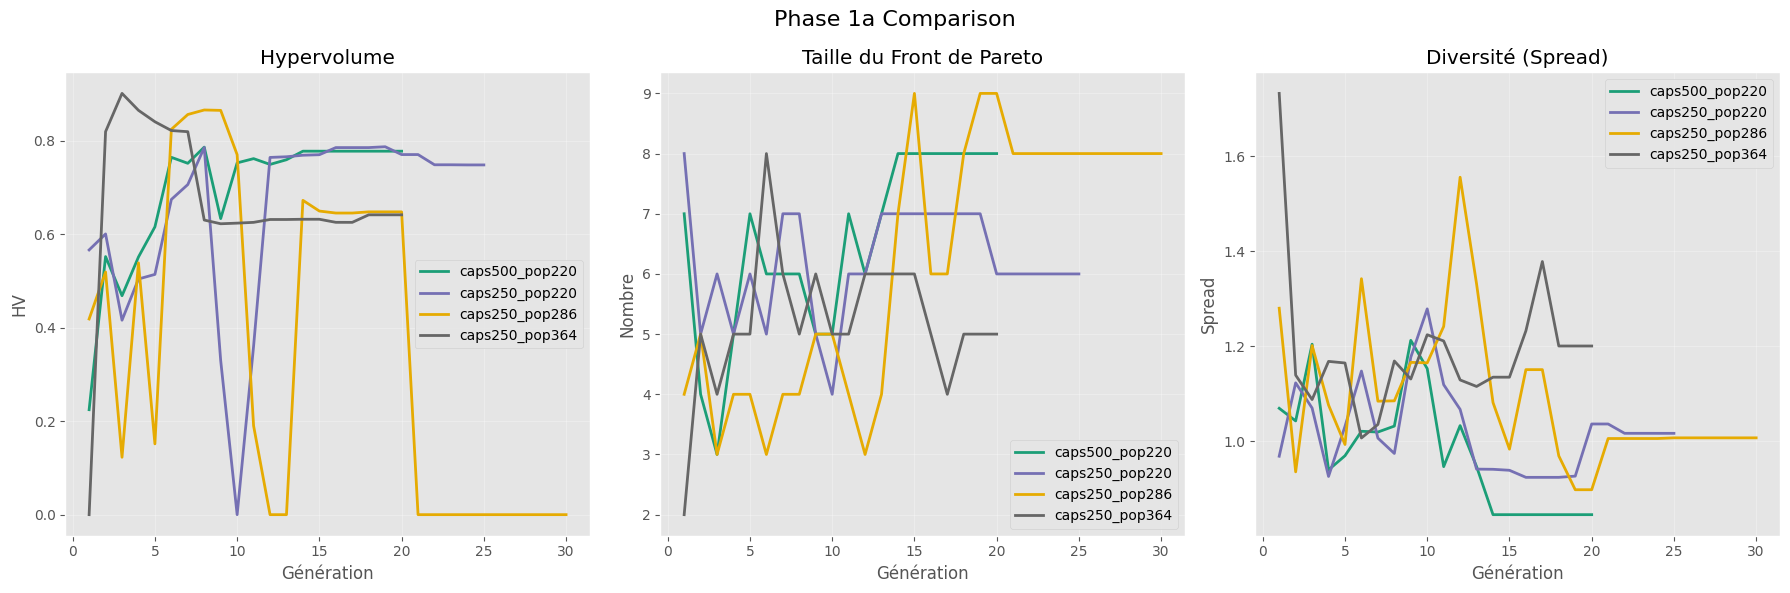

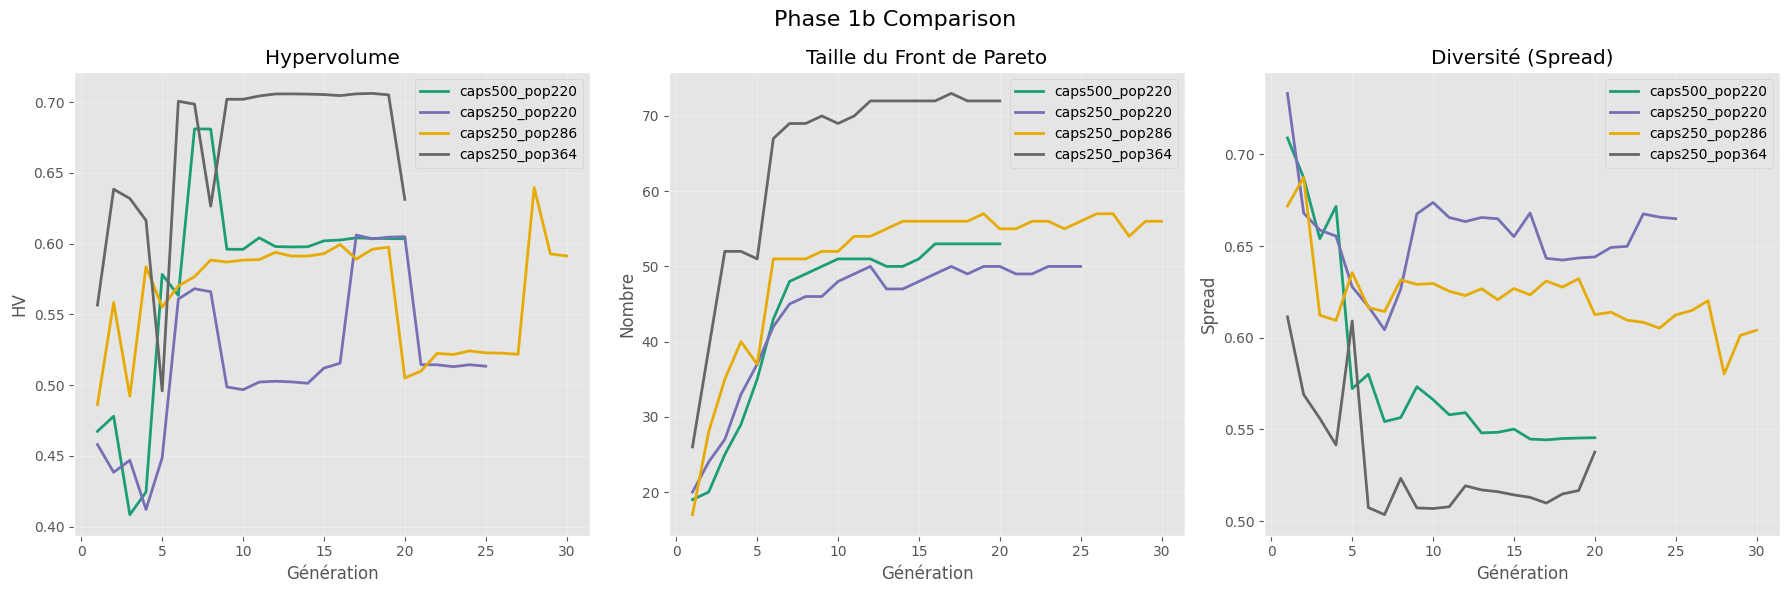

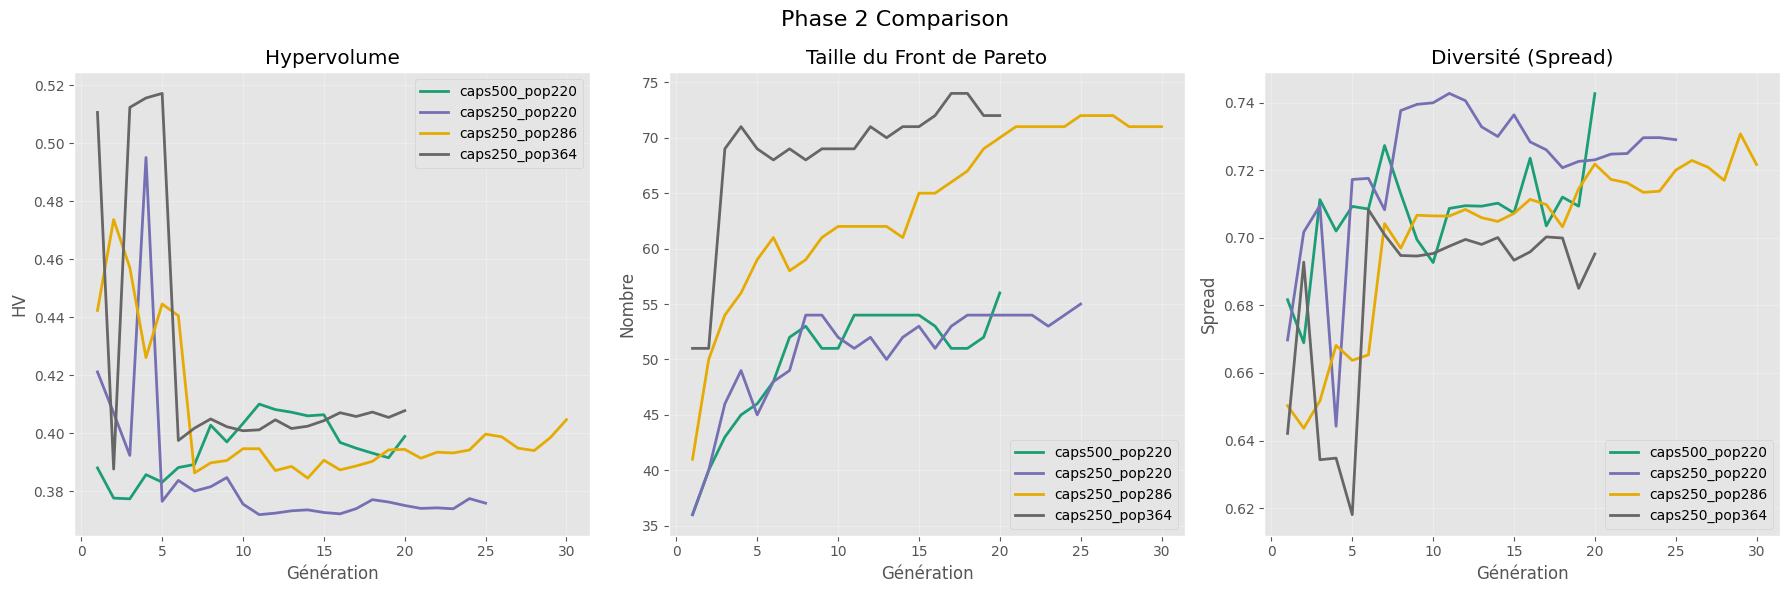

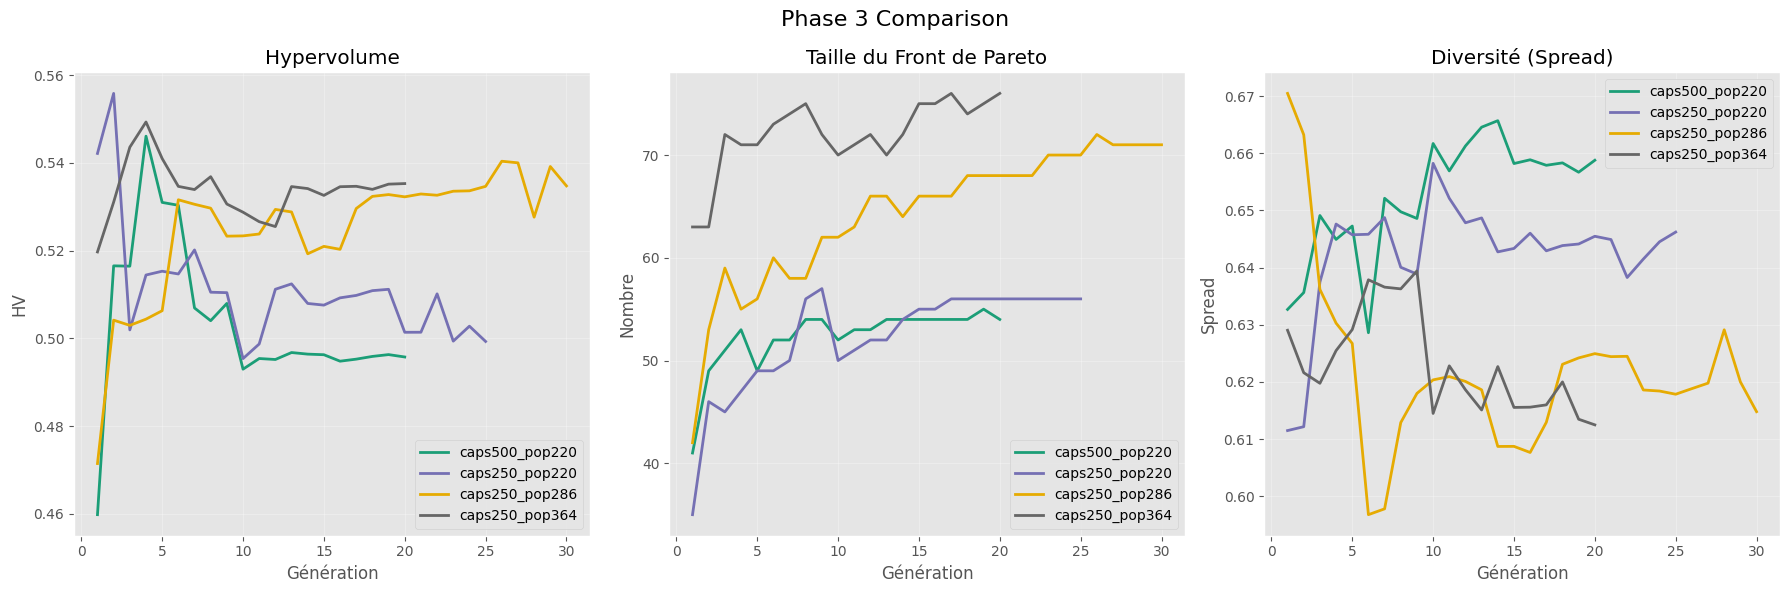

In [13]:
phase1a = NSGA3HistoryAnalyzer.plot_algorithms_comparison({
    "caps500_pop220": opt1.histories["phase_1a"]["res"],
    "caps250_pop220": opt1bis.histories["phase_1a"]["res"],
    "caps250_pop286": opt2.histories["phase_1a"]["res"],
    "caps250_pop364": opt3bis.histories["phase_1a"]["res"],
    }, title="Phase 1a Comparison", figsize=(18,6))

phase1b = NSGA3HistoryAnalyzer.plot_algorithms_comparison({
    "caps500_pop220": opt1.histories["phase_1b"]["res"],
    "caps250_pop220": opt1bis.histories["phase_1b"]["res"],
    "caps250_pop286": opt2.histories["phase_1b"]["res"],
    "caps250_pop364": opt3bis.histories["phase_1b"]["res"],
    }, title="Phase 1b Comparison", figsize=(18,6))

phase1b = NSGA3HistoryAnalyzer.plot_algorithms_comparison({
    "caps500_pop220": opt1.histories["phase_2"]["res"],
    "caps250_pop220": opt1bis.histories["phase_2"]["res"],
    "caps250_pop286": opt2.histories["phase_2"]["res"],
    "caps250_pop364": opt3bis.histories["phase_2"]["res"],
    }, title="Phase 2 Comparison", figsize=(18,6))

phase3 = NSGA3HistoryAnalyzer.plot_algorithms_comparison({
    "caps500_pop220": opt1.histories["phase_3"]["res"],
    "caps250_pop220": opt1bis.histories["phase_3"]["res"],
    "caps250_pop286": opt2.histories["phase_3"]["res"],
    "caps250_pop364": opt3bis.histories["phase_3"]["res"],
    }, title="Phase 3 Comparison", figsize=(18,6))


In [ ]:
# NSGA3HistoryAnalyzer.compare_algorithms({
#     "GA Phase 1a": opt.histories["phase_1a"]["res"],
#     "GA Phase 1b": opt.histories["phase_1b"]["res"],
#     "GA Phase 2": opt.histories["phase_2"]["res"],
#     "GA Phase 3": opt.histories["phase_3"]["res"],
#     })

In [7]:
kpis = opt1.get_kpis()

In [8]:
kpis.get_total_waiting_time()

np.float64(1561.0)

In [23]:
kpis = histories["default_phase3_rotterdam_18k"]["kpis"]

In [24]:
opt1.plot_kpis(kpis)